# CosmoFit — CPL (w0waCDM) MCMC Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/cpl_mcmc_analysis.ipynb)

This notebook is an end-to-end walkthrough of **CosmoFit**: fitting the
**CPL (Chevallier–Polarski–Linder) dark-energy model**,

$$w(z) = w_0 + w_a \frac{z}{1+z},$$

to real cosmological data — Cosmic Chronometers, DESI BAO, and Pantheon+
supernovae — with a full Bayesian MCMC analysis, convergence diagnostics,
the standard publication-style figures, and a model comparison against
flat ΛCDM.

**Running this notebook:** open it in Google Colab and choose
*Runtime → Run all*. The first cell installs CosmoFit and its
dependencies; everything after that just works. Locally, it assumes
CosmoFit is already installed (`pip install -e .` from the repository
root).

**Runtime:** the MCMC cells take a few minutes (CPU-bound; no GPU
needed).


## 1. Setup

Installs CosmoFit + dependencies when running in Google Colab. If you're running this locally from a cloned repository with CosmoFit already installed (`pip install -e .`), this cell does nothing.

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .

    # The editable install above runs in a subprocess, so the .pth /
    # editable-finder file it writes isn't picked up by *this*
    # already-running kernel without a restart. Without this, `import
    # CosmoFit` can resolve to the bare repo checkout directory
    # instead (same name as the package, and `/content` is on
    # sys.path in Colab) -- an empty namespace package with none of
    # LCDM/CPL/Fitter defined, raising a confusing "unknown location"
    # ImportError. Pointing sys.path at src/ directly sidesteps that.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e . from the repository root).")


Not running in Colab -- assuming CosmoFit is already installed (pip install -e . from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import LCDM, CPL, Fitter, PlanckLikelihood
from CosmoFit.stats import model_comparison, cpl_diagnostics
from CosmoFit.data.loader import available_datasets

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)


## 2. Datasets

CosmoFit ships with four built-in observational datasets. The main fit
below uses Cosmic Chronometers, DESI BAO, and Pantheon+ (all fast, purely
late-time background-expansion probes); Planck's compressed CMB distance
priors are used separately in section 11, since including them in the
MCMC (they need an extra numerical integral per step for the sound
horizon) meaningfully slows the chain down.

In [3]:
available_datasets()

{'cc': ['favale2023'],
 'desi': ['desi2024'],
 'sdss_bao': ['dr12+dr16'],
 'pantheon': ['pantheon+sh0es'],
 'des_sn5yr': ['des-sn5yr'],
 'fsigma8': ['gold2018'],
 's8': ['kids1000', 'des_y3'],
 'planck': ['planck2018']}

## 3. Building the CPL fit

Free parameters: $H_0$, $\Omega_m$, $w_0$, $w_a$. The sound horizon
$r_d$ is held fixed at its Planck 2018 fiducial value, since it isn't
constrained by CC+DESI+Pantheon alone without a CMB prior.

In [4]:
fit = Fitter(
    model=CPL,
    datasets=["cc", "desi", "pantheon"],
    free_params=["H0", "Omega_m", "w0", "wa"],
    initial={
        "H0": 67.4,
        "Omega_m": 0.315,
        "w0": -1.0,
        "wa": 0.0,
        "rd": 147.1,
    },
)

fit

Fitter(model=CPL, datasets=['cc', 'desi', 'pantheon'], free_params=['H0', 'Omega_m', 'w0', 'wa'])

In [5]:
print(f"Total data points: {fit.n_data}")
fit.chi2_breakdown()

Total data points: 1668


{'CC': 13.3377083716049,
 'DESI': 20.712473590731655,
 'Pantheon+': 1457.4988513663411}

## 4. Running the MCMC

`Fitter.run_mcmc` wraps `emcee.EnsembleSampler`. The settings below
(32 walkers, 2500 steps) are picked to finish in a few minutes for this
demo; for a publication-quality chain, use more steps (the docstring
default is `nwalkers=48, nsteps=6000, burnin=1000`) and check
`fit.convergence()` -- see the next section.

In [6]:
fit.run_mcmc(nwalkers=32, nsteps=2500, burnin=500, seed=42, progress=True)

100%|██████████| 2500/2500 [00:49<00:00, 50.85it/s]


## 5. Convergence diagnostics

Before trusting any posterior summary or figure below, check that the
chain has actually mixed: the integrated autocorrelation time $\tau$
should be much shorter than the chain length (`converged=True` requires
at least 50$\tau$, `emcee`'s own recommended rule of thumb). Short demo
runs like this one often fall a little short of that -- rerun with more
steps if `converged` is `False` and you need publication-quality
intervals.

In [7]:
conv = fit.convergence()

for name, tau in conv["tau"].items():
    print(f"{name:>10s}:  tau = {tau:6.1f}   n_eff = {conv['n_effective'][name]:7.1f}")

print(f"\nconverged (n_steps >= 50*tau for every parameter): {conv['converged']}")

The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [48.64580564 75.34235495 55.2826414  67.93610815]


        H0:  tau =   48.6   n_eff =  1315.6
   Omega_m:  tau =   75.3   n_eff =   849.5
        w0:  tau =   55.3   n_eff =  1157.7
        wa:  tau =   67.9   n_eff =   942.1

converged (n_steps >= 50*tau for every parameter): False


## 6. Posterior summary and best fit

In [8]:
for name, stats_ in fit.summary().items():
    print(f"{name:>10s} = {stats_['median']:8.4f}  "
          f"+{stats_['plus']:.4f} / -{stats_['minus']:.4f}")

        H0 =  67.9314  +0.7321 / -0.6867
   Omega_m =   0.3109  +0.0185 / -0.0268
        w0 =  -0.8537  +0.0778 / -0.0722
        wa =  -0.5309  +0.6886 / -0.6464


In [9]:
result = fit.best_fit()

print("Best-fit parameters (maximum likelihood):")
for name, value in fit.best_fit_params.items():
    print(f"  {name:>10s} = {value:.4f}")

print(f"\nchi2_min = {fit.best_fit_chi2:.2f}  "
      f"({fit.n_data} data points, {fit.ndim} free parameters)")

Best-fit parameters (maximum likelihood):
          H0 = 67.9859
     Omega_m = 0.3132
          w0 = -0.8525
          wa = -0.5975

chi2_min = 1480.76  (1668 data points, 4 free parameters)


## 7. MCMC diagnostics: chain trace and corner plot

Every plot in CosmoFit lives on `fit.plots` (a `plots.FitPlotter`
instance).

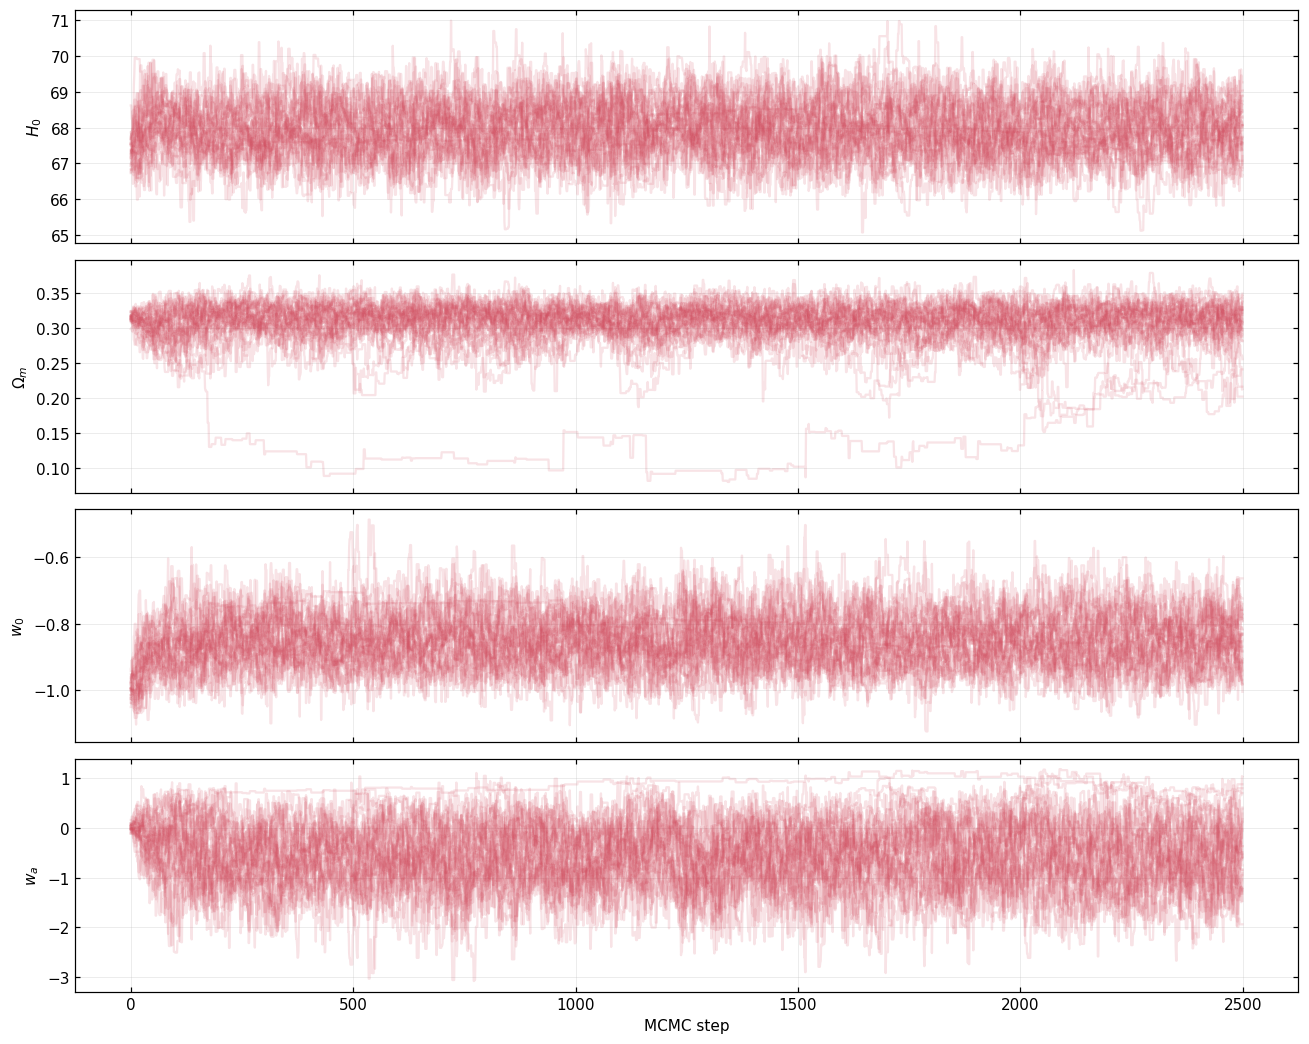

In [10]:
fig = fit.plots.chain()

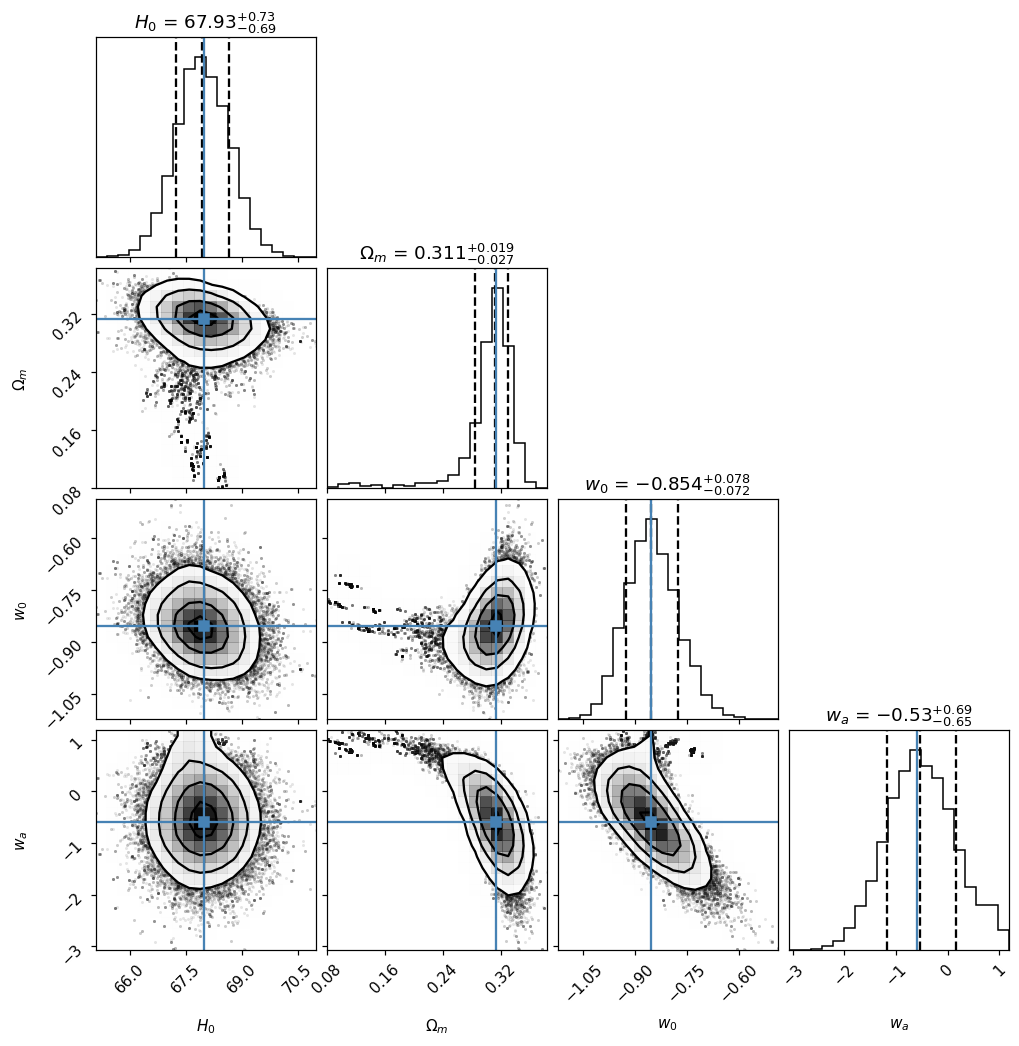

In [11]:
fig = fit.plots.corner(truths=[
    fit.best_fit_params["H0"],
    fit.best_fit_params["Omega_m"],
    fit.best_fit_params["w0"],
    fit.best_fit_params["wa"],
])

## 8. Data vs. model: the standard cosmology figures

Each figure below shows the data against the model evaluated at the
posterior median, with a shaded 68% posterior-predictive band built from
random draws of the MCMC chain (not just a single best-fit curve).

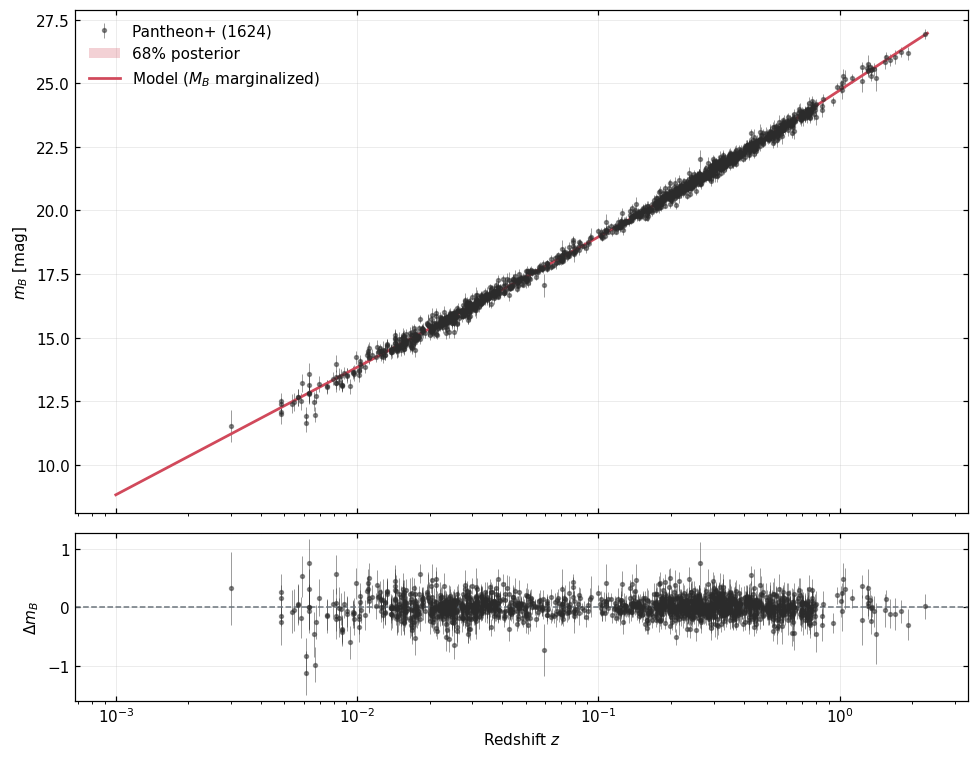

In [12]:
fig = fit.plots.hubble_diagram()

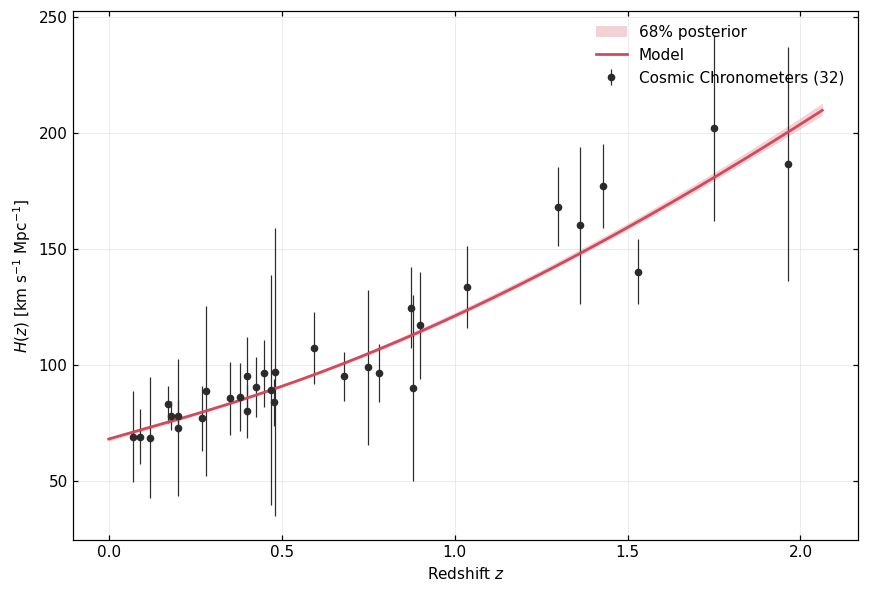

In [13]:
fig = fit.plots.hz()

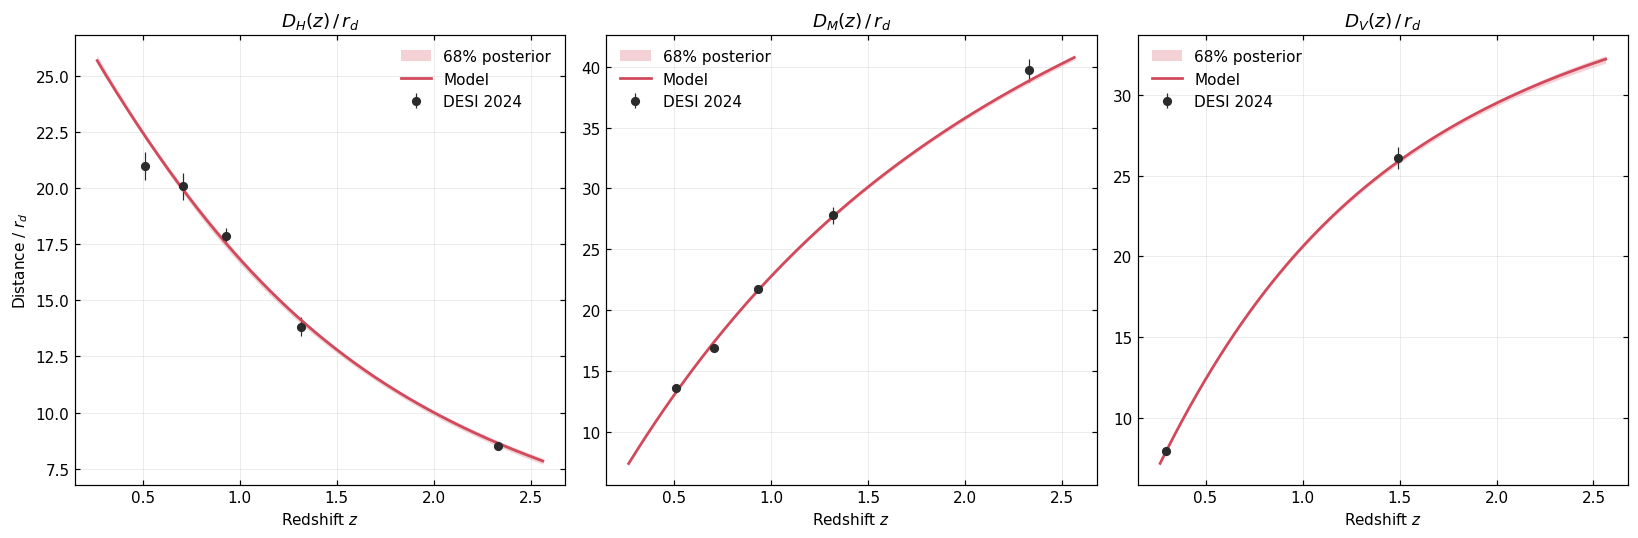

In [14]:
fig = fit.plots.bao_distances()

## 9. Dark-energy equation of state $w(z)$ and the deceleration parameter

CPL's whole point is letting $w(z)$ evolve. The plot below shows the
posterior band for $w(z)$ against the $\Lambda$CDM reference line
$w=-1$, with any $w(z){=}{-1}$ crossing redshifts marked -- and the
deceleration parameter $q(z)$, with the deceleration/acceleration
transition redshift $z_t$ (where $q(z_t)=0$) marked.

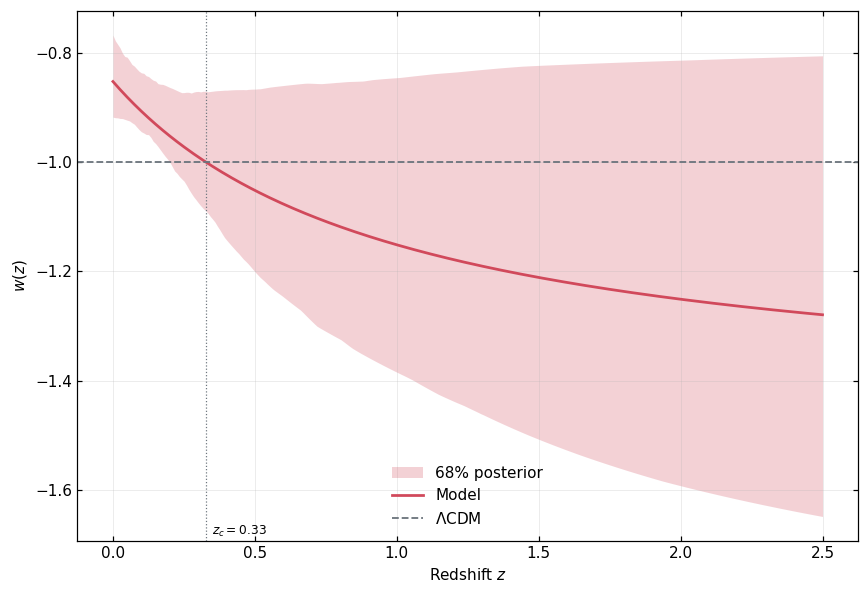

In [15]:
fig = fit.plots.w_of_z()

### The $w_0$-$w_a$ plane

Where the posterior sits relative to $\Lambda$CDM at $(w_0, w_a) =
(-1, 0)$, over the four dark-energy regions: **phantom** ($w < -1$ at
all times), **quintessence** ($w > -1$ at all times), and the two
**quintom** regions where $w(z)$ crosses $-1$ -- which no single
canonical scalar field can do. The boundaries are $w_0 = -1$ (today)
and $w_a = -1 - w_0$ (the high-$z$ limit $w_0 + w_a$).

The contours are 2D credible regions holding 68% and 95% of the
posterior samples.

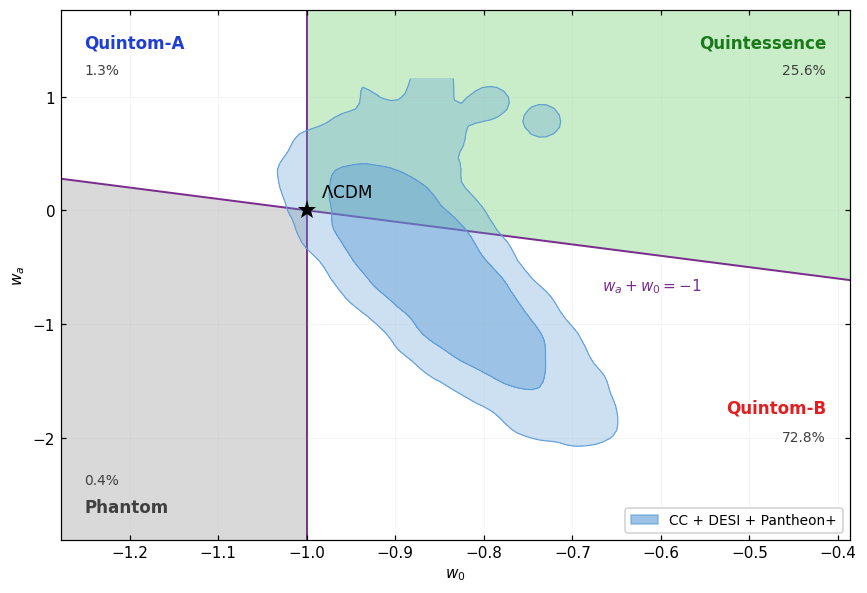

In [16]:
fig = fit.plots.w0_wa_plane(show_fractions=True)


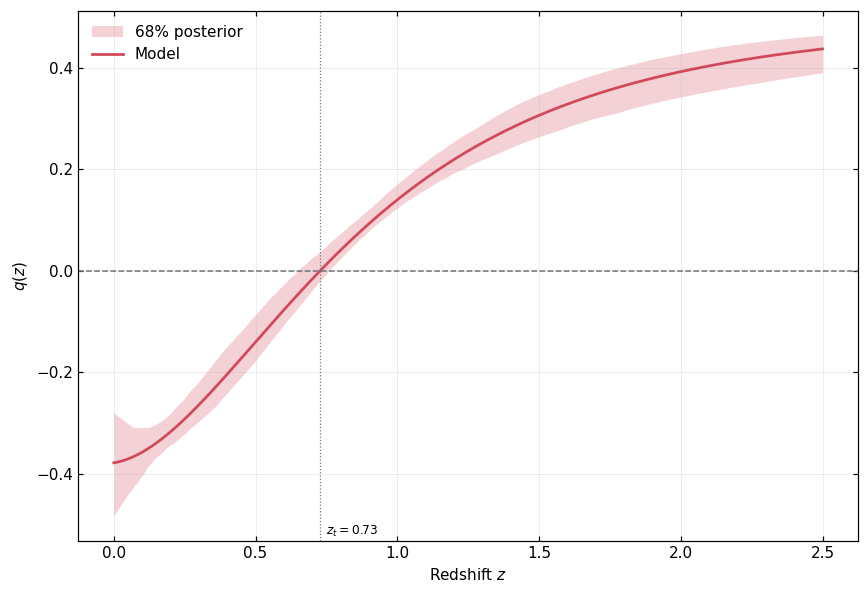

In [17]:
fig = fit.plots.deceleration()

### CPL-specific posterior diagnostics

`stats.cpl_diagnostics` turns the $(w_0, w_a)$ posterior into the
quantities dark-energy papers usually quote: the $w(z)=-1$ crossing
redshift distribution, its direction (quintessence-like $\to$
phantom-like or the reverse), and how many "sigma" away the $\Lambda$CDM
point $(w_0, w_a) = (-1, 0)$ sits from the 2D posterior.

In [18]:
samples = fit.samples_dict()

z_cross, frac_cross = cpl_diagnostics.crossing_redshift(samples["w0"], samples["wa"])
print(f"w(z)=-1 crossing: {frac_cross:.1%} of samples cross in [0, 2.5], "
      f"at z = {np.median(z_cross):.2f} (median) if they do")

if len(z_cross) > 0:
    direction = cpl_diagnostics.crossing_direction(samples["w0"], samples["wa"])
    print(f"  quintessence -> phantom: {direction['quintessence_to_phantom']:.1%}")
    print(f"  phantom -> quintessence: {direction['phantom_to_quintessence']:.1%}")

regions = cpl_diagnostics.region_fractions(samples["w0"], samples["wa"])
print("\nDark-energy region of the (w0, wa) plane:")
for region, fraction in regions.items():
    print(f"  {region:>13s}: {fraction:6.1%}")

lcdm_distance = cpl_diagnostics.mahalanobis_from_lcdm(samples["w0"], samples["wa"])

# Report `sigma`, not `distance`. In 2D the Mahalanobis distance D is
# not a number of sigma: D^2 follows chi-square with 2 degrees of
# freedom, so D = 2.49 (not 2.00) is what encloses the "2 sigma"
# probability. Quoting D directly overstates the tension with LCDM.
print(f"\nLCDM point (w0, wa) = (-1, 0) vs the CPL posterior mean "
      f"{tuple(np.round(lcdm_distance['mean'], 3))}:")
print(f"  Mahalanobis distance D = {lcdm_distance['distance']:.2f} "
      f"(a distance, not a significance)")
print(f"  excluded at {lcdm_distance['confidence_level']:.2%} confidence "
      f"(p = {lcdm_distance['p_value']:.4f}, 2 d.o.f.)")
print(f"  => {lcdm_distance['sigma']:.2f} sigma equivalent")

w(z)=-1 crossing: 71.8% of samples cross in [0, 2.5], at z = 0.26 (median) if they do
  quintessence -> phantom: 98.2%
  phantom -> quintessence: 1.8%

Dark-energy region of the (w0, wa) plane:
        phantom:   0.4%
   quintessence:  25.6%
      quintom-a:   1.3%
      quintom-b:  72.8%

LCDM point (w0, wa) = (-1, 0) vs the CPL posterior mean (np.float64(-0.85), np.float64(-0.511)):
  Mahalanobis distance D = 2.12 (a distance, not a significance)
  excluded at 89.42% confidence (p = 0.1058, 2 d.o.f.)
  => 1.62 sigma equivalent


## 10. Model comparison: CPL vs. flat $\Lambda$CDM

Is the extra freedom of CPL ($w_0$, $w_a$) actually preferred by the
data over flat $\Lambda$CDM, once model complexity is penalized? Fit
$\Lambda$CDM to the *same* three datasets and compare with AIC, BIC, and
a likelihood-ratio test (valid since $\Lambda$CDM is CPL's nested
special case at $w_0=-1,\ w_a=0$).

In [19]:
fit_lcdm = Fitter(
    model=LCDM,
    datasets=["cc", "desi", "pantheon"],
    free_params=["H0", "Omega_m"],
    initial={"H0": 67.4, "Omega_m": 0.315, "rd": 147.1},
)

fit_lcdm.run_mcmc(nwalkers=16, nsteps=1500, burnin=300, seed=42, progress=True)
fit_lcdm.best_fit()

print(f"LCDM  chi2_min = {fit_lcdm.best_fit_chi2:.2f}  ({fit_lcdm.ndim} free parameters)")
print(f"CPL   chi2_min = {fit.best_fit_chi2:.2f}  ({fit.ndim} free parameters)")

100%|██████████| 1500/1500 [00:18<00:00, 82.07it/s]


LCDM  chi2_min = 1485.21  (2 free parameters)
CPL   chi2_min = 1480.76  (4 free parameters)


In [20]:
comparison = model_comparison.compare_models(
    name_null="LCDM",
    chi2_null=fit_lcdm.best_fit_chi2,
    k_null=fit_lcdm.ndim,
    name_alt="CPL",
    chi2_alt=fit.best_fit_chi2,
    k_alt=fit.ndim,
    n_data=fit.n_data,
)

for name in ("LCDM", "CPL"):
    row = comparison[name]
    print(f"{name:>5s}:  chi2={row['chi2']:8.2f}   AIC={row['AIC']:8.2f}   BIC={row['BIC']:8.2f}")

print(f"\ndelta_AIC (LCDM - CPL) = {comparison['delta_AIC']:+.2f}   "
      f"(positive favors CPL)")
print(f"delta_BIC (LCDM - CPL) = {comparison['delta_BIC']:+.2f}   "
      f"(BIC penalizes extra parameters more strongly than AIC)")

lrt = comparison["likelihood_ratio_test"]
print(f"\nLikelihood-ratio test: delta_chi2={lrt['delta_chi2']:.2f} "
      f"(delta_k={lrt['delta_k']}), p={lrt['p_value']:.3f}, "
      f"{lrt['sigma']:.2f} sigma preference for CPL over LCDM")

 LCDM:  chi2= 1485.21   AIC= 1489.21   BIC= 1500.05
  CPL:  chi2= 1480.76   AIC= 1488.76   BIC= 1510.44

delta_AIC (LCDM - CPL) = +0.45   (positive favors CPL)
delta_BIC (LCDM - CPL) = -10.39   (BIC penalizes extra parameters more strongly than AIC)

Likelihood-ratio test: delta_chi2=4.45 (delta_k=2), p=0.108, 1.24 sigma preference for CPL over LCDM


A modest AIC/BIC improvement or a low-significance likelihood-ratio
result here is not a discovery of evolving dark energy -- it just means
these three background-expansion datasets alone don't yet strongly
prefer one model over the other. (Compare with DESI's own 2024 CPL
analysis, which combines BAO with CMB and multiple SN compilations and
finds a few-sigma preference for evolving dark energy in some
combinations -- worth reproducing here once more data / longer chains
are used.)

## 11. CPL vs. flat $\Lambda$CDM: side-by-side comparison plots

The AIC/BIC/likelihood-ratio numbers above say *whether* CPL is
statistically preferred; these figures show *what that difference
actually looks like*. Every `fit.plots.*` figure has a `compare_*`
counterpart that overlays this fit's curve with one or more other
models' curves on the same data/axes -- `fit.plots.compare_hz(other_fits=fit_lcdm)`
here, since `fit_lcdm` was already built and MCMC-fit above for the
model-comparison section. (Left on its own, `compare_hz()` etc. would
auto-build a quick best-fit-only $\Lambda$CDM reference for exactly
this comparison -- passing `fit_lcdm` explicitly just reuses the full
MCMC posterior we already have instead.) This works for any model
CosmoFit knows about (built-in or [custom](https://github.com/salihyesil59/CosmoFit#custom-models)),
and for more than two at once via `other_fits=[fit_a, fit_b, ...]`.

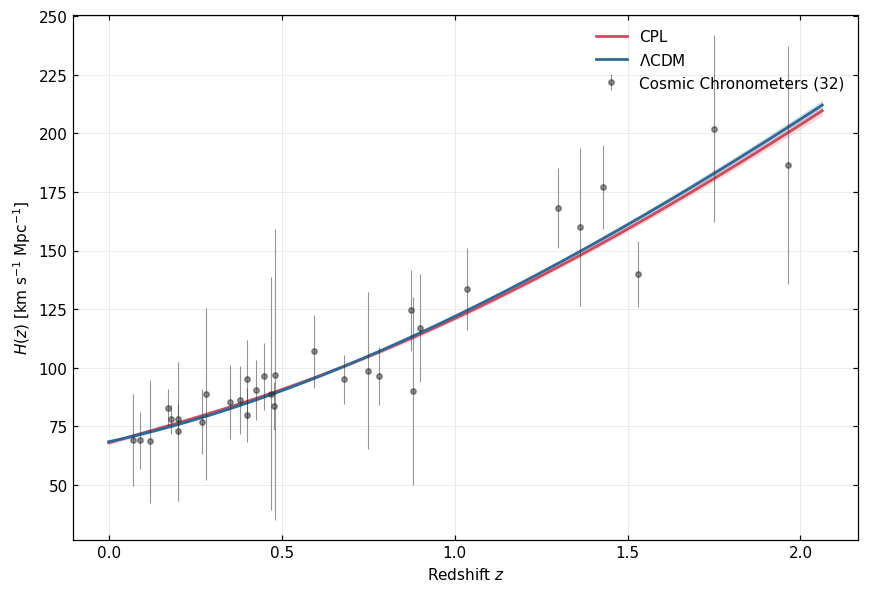

In [21]:
fig = fit.plots.compare_hz(other_fits=fit_lcdm)

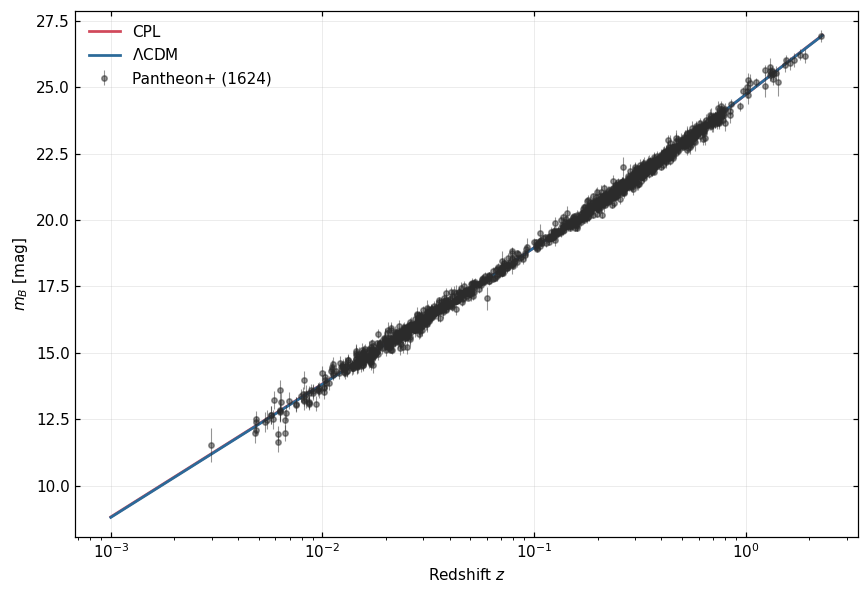

In [22]:
fig = fit.plots.compare_hubble_diagram(other_fits=fit_lcdm)

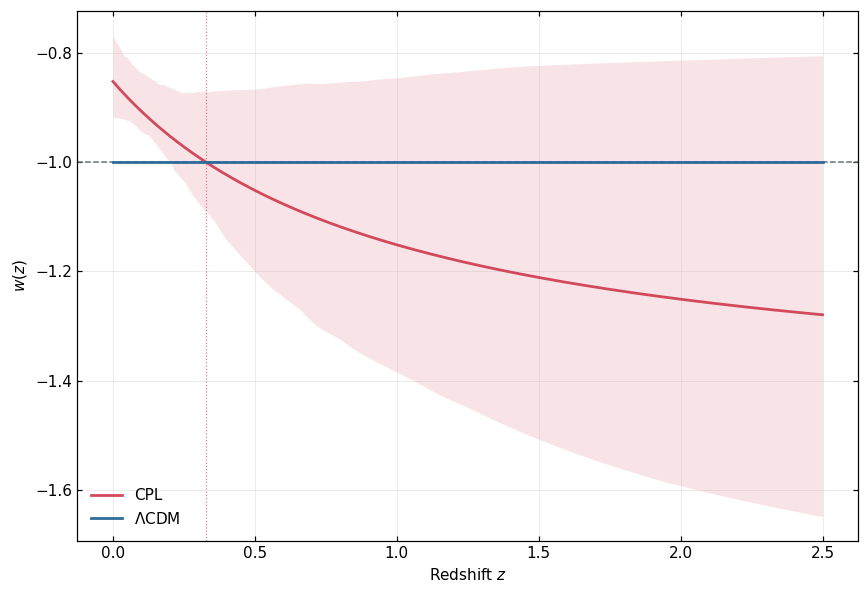

In [23]:
fig = fit.plots.compare_w_of_z(other_fits=fit_lcdm)

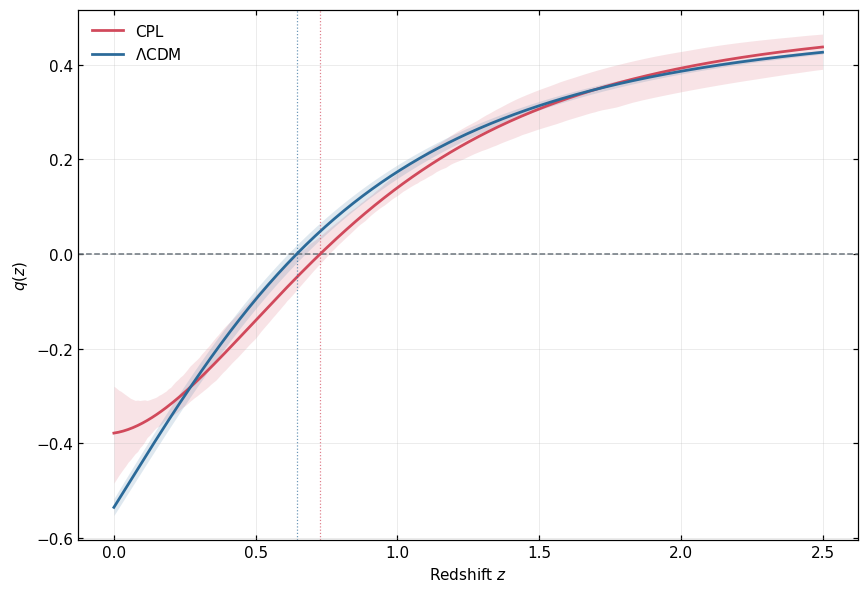

In [24]:
fig = fit.plots.compare_deceleration(other_fits=fit_lcdm)

Each curve above marks its own deceleration/acceleration transition redshift $z_t$ (where $q(z_t)=0$) -- CPL's evolving $w(z)$ shifts $z_t$ relative to $\Lambda$CDM's, which is exactly the kind of difference AIC/BIC alone don't show.

## 12. An independent check: Planck CMB distance priors

The Planck 2018 compressed distance-prior likelihood
($R$, $\ell_A$, $\omega_b h^2$) wasn't included in the fit above,
so we can use it as an independent consistency check of the CPL
best-fit point (it also needs $\Omega_b$ and $r_d$, which the fit above
didn't constrain -- both are left at their Planck fiducial defaults
here).

Planck chi2 at the CPL best-fit point: 45.37  (3 data points)


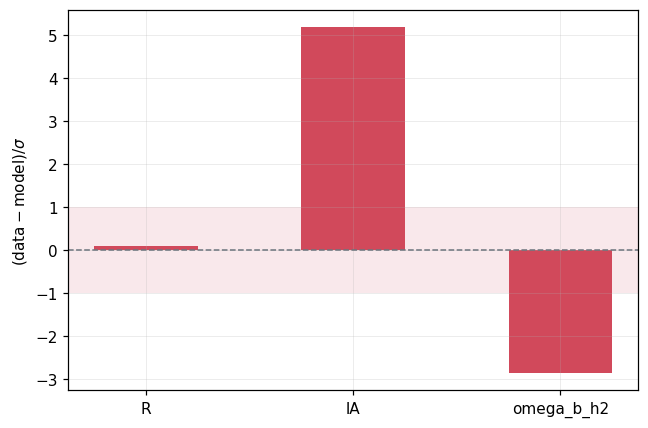

In [25]:
planck = PlanckLikelihood(fit.cosmology)

print(f"Planck chi2 at the CPL best-fit point: {planck.chi2():.2f}  (3 data points)")

# `planck` here is a standalone likelihood, not part of `fit`'s own
# dataset list, so `fit.plots.planck_residuals()` (which looks up the
# Planck likelihood *among fit.likelihoods*) doesn't apply -- build the
# same pull plot directly instead.
pull = planck.residuals() / planck.covariance.sigma

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0.0, color="#6c757d", lw=1.0, ls="--")
ax.axhspan(-1, 1, color="#d1495b", alpha=0.12, linewidth=0)
ax.bar(range(len(pull)), pull, color="#d1495b", width=0.5)
ax.set_xticks(range(len(pull)))
ax.set_xticklabels(planck.data.labels)
ax.set_ylabel(r"$(\mathrm{data} - \mathrm{model}) / \sigma$")
ax.grid(alpha=0.25, linewidth=0.6)
fig.tight_layout()

## Summary

This notebook fit the CPL dark-energy model to Cosmic Chronometers,
DESI BAO, and Pantheon+ supernovae with a full MCMC analysis, checked
chain convergence, produced the standard cosmology-paper figures
(Hubble diagram, $H(z)$, BAO distances, $w(z)$ evolution, deceleration
parameter), compared CPL against flat $\Lambda$CDM with AIC/BIC/a
likelihood-ratio test and side-by-side comparison plots ($H(z)$,
Hubble diagram, $w(z)$, deceleration parameter -- CPL and $\Lambda$CDM
on the same axes), and cross-checked the result against Planck's CMB
distance priors.

For a longer, publication-grade run: increase `nsteps` (and rerun
`fit.convergence()` until `converged=True`), and consider adding
`"planck"` to `datasets=[...]` to break the $H_0$-$\Omega_m$-$r_d$
degeneracies the late-time-only fit above can't resolve on its own.

See the [CosmoFit README](https://github.com/salihyesil59/CosmoFit) for
the full API.